# Plot Reflected Solar for Paulette Base Run

This creates a visual comparison for hurricane Paulette between MODIS and ICON.

Using levante python kernel "1 Python 3" (can be recreated from `../environment-standard.yml`)

## Libraries

In [1]:
import numpy as np
import xarray as xr

import pylab as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import seaborn as sns
sns.set_context( 'talk' )

## Input

### Input Grid

In [2]:
grid_name = '/work/bb1376/data/icon/grids-extpar/atlanXL/atlanXL_R02B10_DOM02.nc'
grid = xr.open_dataset( grid_name )

### Input Radiation Data

In [3]:
rad_name = '/work/bb1376/data/icon/atlantic-cases/paulette/ifces2-atlanXL-20200907-exp021/DATA/2d_rad_DOM02_ML_20200914T180000Z.nc'
rad = xr.open_dataset( rad_name ).squeeze()

## Analysis

In [4]:
sou = rad['sod_t'] - rad['sob_t']

vmin = 100.
vmax = 750. # sou.quantile( 0.98 ).compute()

## Plotting

### Utilities

In [5]:
# Create the colormap
colors = ['#0c1429', 'white']
n_bins = 256  # Number of discrete colors in the colormap
cmap = mcolors.LinearSegmentedColormap.from_list('white_to_dark', colors, N=n_bins)

In [6]:
voc = grid['vertex_of_cell'].T - 1

vlon, vlat = np.rad2deg( grid['vlon']), np.rad2deg( grid['vlat'] )
tri = plt.matplotlib.tri.Triangulation( vlon, vlat, triangles=voc)

### Full

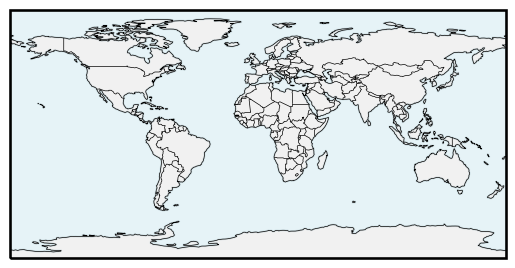

In [7]:
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.3)
ax.add_feature(cfeature.LAND, color='lightgray', alpha=0.3)

# ax.tripcolor( tri, sou, cmap = cmap, vmax = sou90.data) 

### Cutout

In [8]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from cartopy.mpl.geoaxes import GeoAxes

def add_scale_bar(ax, extent, length_km=100, offset=(0.05, 0.05)):
    lon_min, lon_max, lat_min, lat_max = extent

    lat_bar = lat_min + offset[1] * (lat_max - lat_min)
    lon_right = lon_max - offset[0] * (lon_max - lon_min)

    km_per_deg_lon = 111.32 * np.cos(np.radians(lat_bar))
    delta_lon = length_km / km_per_deg_lon
    lon_left = lon_right - delta_lon

    ax.plot([lon_left, lon_right], [lat_bar, lat_bar],
            color='white', linewidth=2.5, transform=ccrs.PlateCarree(), zorder=5)

    tick_height = (lat_max - lat_min) * 0.008
    for lon_tick in [lon_left, lon_right]:
        ax.plot([lon_tick, lon_tick], [lat_bar - tick_height, lat_bar + tick_height],
                color='white', linewidth=2.5, transform=ccrs.PlateCarree(), zorder=5)

    ax.text((lon_left + lon_right) / 2, lat_bar + tick_height * 2,
            f'{length_km} km',
            color='white', fontsize=12, ha='center', va='bottom',
            transform=ccrs.PlateCarree(), zorder=5, fontweight='bold')


def add_overview_inset(fig, ax, extent):
    """
    Add a global overview inset (top-right) showing the region as a red box.
    """
    lon_min, lon_max, lat_min, lat_max = extent

    # Get parent axes position in figure fraction
    pos = ax.get_position()  # [x0, y0, width, height]

    # Place inset in top-right of the parent axes
    inset_w, inset_h = 0.12, 0.18
    inset_x = pos.x0 + pos.width  - inset_w - 0.00   # right-aligned with small margin
    inset_y = pos.y0 + pos.height - inset_h - 0.02   # top-aligned with small margin

    ax_inset = fig.add_axes(
        [inset_x, inset_y, inset_w, inset_h],
        projection=ccrs.Orthographic(
            central_longitude=(lon_min + lon_max) / 2,
            central_latitude=(lat_min + lat_max) / 2
        )
    )

    # Globe features
    ax_inset.set_global()
    ax_inset.add_feature(cfeature.OCEAN,     color='black', zorder=0)
    ax_inset.add_feature(cfeature.LAND,      color='olive', zorder=1)
    #ax_inset.add_feature(cfeature.COASTLINE, color = 'white',linewidth=0.3, alpha  =0.5, zorder=2)

    # Red bounding box of the region
    box_lons = [lon_min, lon_max, lon_max, lon_min, lon_min]
    box_lats = [lat_min, lat_min, lat_max, lat_max, lat_min]
    ax_inset.plot(box_lons, box_lats,
                  color='crimson', linewidth=1.2, transform=ccrs.PlateCarree(), zorder=3)

    # Thin border
    for spine in ax_inset.spines.values():
        spine.set_edgecolor('lightgray')
        spine.set_linewidth(2)


    return ax_inset

<GeoAxes:>

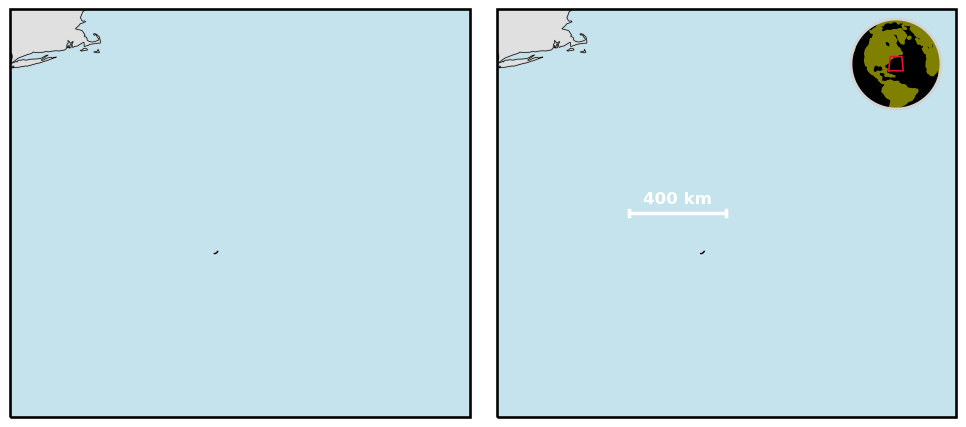

In [9]:
extent = [-73.97489896385542, -53.43340103614459, 24.969199999999994, 43.20779999999999]
# --- Usage ---
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())

# Add map features
for ax in [ax1,ax2]:
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.7)
    ax.add_feature(cfeature.LAND, color='lightgray', alpha=0.7)
    
    # ax.tripcolor( tri, sou, cmap = cmap ) 
    ax.set_extent(extent, crs=ccrs.PlateCarree())
plt.tight_layout()

add_scale_bar(ax2, extent, length_km=400, offset=(0.5, 0.5))

add_overview_inset(fig, ax2, extent)


Original CRS: EPSG:4326
Bounds: BoundingBox(left=-73.97489896385542, bottom=24.969199999999994, right=-53.43340103614459, top=43.20779999999999)
Shape: (4, 2075, 2337)
Shape after: (2075, 2337, 3)
Final data shape before plotting: (2075, 2337, 3)
Plotting RGB image


/sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-kptncg/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


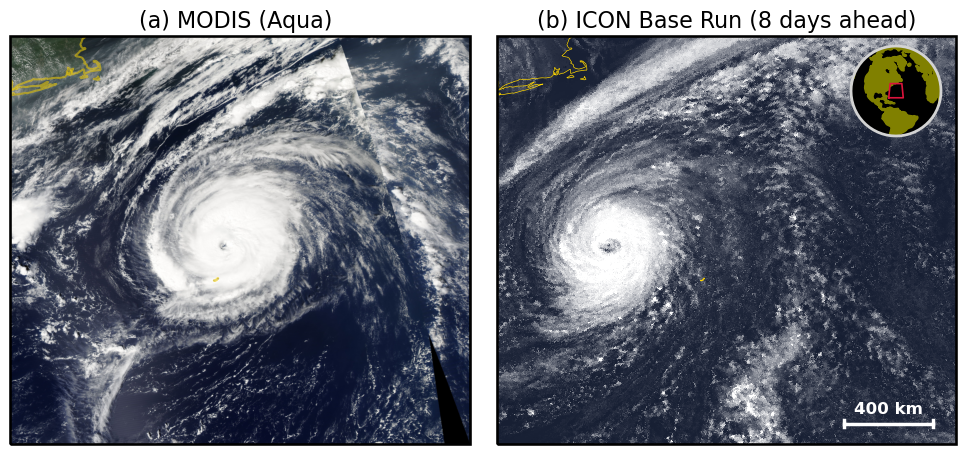

In [10]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rasterio
from rasterio.plot import show
from rasterio.warp import calculate_default_transform, reproject, Resampling
import numpy as np

def get_geotiff(geotiff_path, ):
    """
    Plot a GeoTIFF from NASA Worldview using matplotlib and cartopy
    
    Parameters:
    geotiff_path: str - Path to your GeoTIFF file
    figsize: tuple - Figure size (width, height)
    """
    
    # Read the GeoTIFF
    with rasterio.open(geotiff_path) as src:
        # Get the data
        data = src.read()
        
        # Get geospatial information
        bounds = src.bounds
        crs = src.crs
        transform = src.transform
        
        print(f"Original CRS: {crs}")
        print(f"Bounds: {bounds}")
        print(f"Shape: {data.shape}")
        
        # For RGB images, we need to handle multi-band data
        if data.shape[0] == 4:  # RGBA
            data = np.transpose(data, (1, 2, 0))
            data = data[:, :, :3]  # Drop alpha channel

        if data.shape[0] == 3:  # RGB
            # Rearrange from (bands, height, width) to (height, width, bands)
            data = np.transpose(data, (1, 2, 0))
            # Normalize if values are in 0-255 range

        elif data.shape[0] == 1:  # Single band
            data = data[0]
        
        if data.max() > 1:
                data = data / 255.0

        print(f"Shape after: {data.shape}")
        
        
        # Create figure with subplots
        
        # Convert CRS to cartopy CRS
        if crs.to_string() == 'EPSG:4326':
            cartopy_crs = ccrs.PlateCarree()
        elif crs.to_string().startswith('EPSG:326'):  # UTM North
            zone = int(crs.to_string().split(':')[1][3:])
            cartopy_crs = ccrs.UTM(zone)
        else:
            # For other projections, try to use PlateCarree as fallback
            cartopy_crs = ccrs.PlateCarree()

        return data, bounds, crs, cartopy_crs

def plot_geotiff(data, bounds, crs, cartopy_crs):

        # Plot 1: Original GeoTIFF
        fig = plt.gcf()
        ax1 = fig.add_subplot(1, 2, 1, projection=cartopy_crs)
        
        # Set extent based on bounds
        ax1.set_extent([bounds.left, bounds.right, bounds.bottom, bounds.top], 
                       crs=cartopy_crs)
        
        # Plot the image
        extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
        print(f"Final data shape before plotting: {data.shape}")
        
        if len(data.shape) == 3 and data.shape[2] == 3:  # RGB
            print("Plotting RGB image")
            ax1.imshow(data, extent=extent, transform=cartopy_crs, origin='upper')
        elif len(data.shape) == 2:  # Single band
            print("Plotting single band image")
            im1 = ax1.imshow(data, extent=extent, transform=cartopy_crs, 
                           origin='upper', cmap='viridis')
            plt.colorbar(im1, ax=ax1, shrink=0.8)
        else:
            print(f"Warning: Unexpected final shape {data.shape}, using first band")
            plot_data = data[0] if len(data.shape) > 2 else data
            im1 = ax1.imshow(plot_data, extent=extent, transform=cartopy_crs, 
                           origin='upper', cmap='viridis')
            plt.colorbar(im1, ax=ax1, shrink=0.8)
        
        # Add map features
        ax1.add_feature(cfeature.COASTLINE, alpha=0.5, color = 'gold')
        ax1.add_feature(cfeature.BORDERS, alpha=0.5)
                
        return ax1

# Example usage:
if __name__ == "__main__":
    # Replace with your actual file path
    geotiff_path = "/home/b/b380352/pub/2025-08_hurricane-centric-paper/data/snapshot-2020-09-14T00_00_00Z.tif"
    
    # Example: Plot just the GeoTIFF
    fig = plt.figure(figsize = (10,5))
    data, bounds, crs, cartopy_crs  = get_geotiff(geotiff_path)
    ax1 = plot_geotiff( data, bounds, crs, cartopy_crs )

    
    # Example: Your dataset (replace with actual data)
    # your_lons = np.linspace(-180, 180, 360)
    # your_lats = np.linspace(-90, 90, 180)
    # your_data = np.random.random((180, 360))
    # Add map features
    ax = fig.add_subplot(1, 2, 2, projection=cartopy_crs)

    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color = 'gold')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    ax.tripcolor( tri, sou, cmap = cmap,vmin = vmin, vmax = vmax) 
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
    ax.set_extent(extent, crs=ccrs.PlateCarree())
        
    ax1.set_title('(a) MODIS (Aqua) ', fontsize = 16)
    ax.set_title('(b) ICON Base Run (8 days ahead)', fontsize = 16)
    add_scale_bar(ax, extent, length_km=400)

    # to visualize shift
    #add_scale_bar(ax, extent, length_km=400, offset=(0.55, 0.5), color = 'gold')
    #add_scale_bar(ax1, extent, length_km=400, offset=(0.55, 0.5), color = 'gold')
    
    plt.tight_layout()
    add_overview_inset(fig, ax, extent)

    # Complete comparison
    # plot_side_by_side_comparison(geotiff_path, your_data, your_lons, your_lats)
    
    plt.savefig('../pics/comparison-paulette-from-modis-and-icon-base.png', dpi = 300)